## LDA 토픽 모델링
- 데이터 수집 : 네이버 영화 관람평
- 형태소 분석 : 형태소 분석기 활용 (KoNLPy)
- 벡터화 표현 : TF-IDE 변환 (텍스트 데이터 > 벡터화)
- 토픽 모델링 : LDA 기법 토픽 모델링
- 시각화 : pyLDAvis 라이브러러리 설치, 모델링 결과 해석

In [ ]:
import pandas as pd
from tqdm import tqdm

### 수집 데이터 확인

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/'
reviews = pd.read_pickle(path+'movie_reviews_20240419.pkl')
reviews.shape, reviews['movieCd'].nunique()

((68877, 10), 202)

### 형태소 분석

In [ ]:
!pip install konlpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 58.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.6/488.6 kB 41.6 MB/s eta 0:00:00


In [ ]:
sample_text = reviews['clean_review'].iloc[0]
print(type(sample_text))
print(sample_text)

<class 'str'>
기대를 져버리지 않는 송민경


In [ ]:
from konlpy.utils import pprint
from konlpy.tag import Okt
# Open Korean Text: 오픈 소스 한국어 분석기. 과거 트위터 형태소 분석기.

okt = Okt()
print(okt)

In [ ]:
# ✅ pos 로 품사 태깅
tokens = okt.pos(sample_text)
pprint(tokens)

[('기대', 'Noun'),
 ('를', 'Josa'),
 ('져', 'Verb'),
 ('버리지', 'Verb'),
 ('않는', 'Verb'),
 ('송민경', 'Noun')]


In [ ]:
# ✅ morphs 로 모든 형태소 반환, nouns 로 명사만 반환
tokens = okt.morphs(sample_text)
pprint(tokens)

['기대', '를', '져', '버리지', '않는', '송민경']


In [ ]:
# 명사
tokens = okt.nouns(sample_text)
pprint(tokens)

['기대', '송민경']


In [ ]:
# 한 영화의 모든 리뷰의 명사 추출
# 영화 종류 162개

# 3글자 이상의 명사 수집
def cleaned_review(df, movie_name, chk='morphs', review_col='kospacing_sent'):
  df = df[df['movieNm'] == movie_name ]
  df = df[(df['별점'] =='9')|(df['별점'] =='10')]
  review_data = df[review_col].dropna().values
  # print(review_data.shape)
  # print(review_data[0])

  if chk == 'nouns':
    cleaned_review_data = []

    for review in tqdm(review_data):
      tokens = okt.nouns(review)
      cleaned_tokens = []

      for word in tokens:
        if len(word) > 2:
          cleaned_tokens.append(word)
        else:
          pass
      cleaned_review = " ".join(cleaned_tokens)
      cleaned_review_data.append(cleaned_review)

  # 품사태깅
  elif chk == 'pos':
    cleaned_review_data = []

    for review in tqdm(review_data):
      tokens = okt.pos(review)
      cleaned_tokens = []

      for word in tokens:
        if len(word) > 2:
          cleaned_tokens.append(word)
        else:
          pass
      cleaned_review = " ".join(cleaned_tokens)
      cleaned_review_data.append(cleaned_review)

  # 모든 형태소 반환
  elif chk == 'morphs':
    cleaned_review_data = []

    for review in tqdm(review_data):
      tokens = okt.morphs(review)
      cleaned_tokens = []

      for word in tokens:
        if len(word) > 2:
          cleaned_tokens.append(word)
        else:
          pass
      cleaned_review = " ".join(cleaned_tokens)
      cleaned_review_data.append(cleaned_review)

  # print(len(cleaned_review_data))
  # print(cleaned_review_data[0])

  return cleaned_review_data

In [ ]:
# reviews['kospacing_sent']

0        임시완은 항상 캐릭터 몰입에 진심인 듯 하지만 이번에는 특히나 실존 인물에 대한 존...
1                            임시완 진짜 대단함 박수 쳤다는 사람들 말이 이 해됨
2        국뽕이니 어쩌고 해도 없는 사실을 꾸며 낸 것도 아니고 역사적 사실을 바탕에 둔 것...
3                   뻔할 줄 알았는데 후반부에 임시완과 호흡을 맞추고 있는 나를 보게 됨
4                  부모님이랑 같이 봤는데 좋아하셔서 괜히 내가 뿌듯 보는데 긴장감 미쳤음
                               ...                        
33917    전반적 만족도는 개인 취향에 따라 다르겠지만 나에겐 10점 일단 닥터차의 기대를 안...
33918             딴 거 볼 거 없어서 기대 안하고 멍 때리며 봤는데 생각보다 꽤 재밌었음
33919                                극한 직업 이후 간 만에 재밌게 봤어요
33920                          너무나도 재밉게 아주 잘 봤어요 너무나도 굿입니다
33921                                 존 x 우낌 송새벽 짱 재밌게 봤슴다
Name: kospacing_sent, Length: 33922, dtype: object

In [ ]:
# reviews_movie_li = reviews[['movieNm','movieCd']].drop_duplicates()

tmp = []
for movie_nm in list(reviews_movie_li['movieNm']):
  data = cleaned_review(reviews, movie_nm, chk='morphs', review_col='clean_review')
  tmp.append(data)

reviews_movie_li['긍정리뷰'] = tmp

100%|██████████| 140/140 [00:00<00:00, 390.57it/s]
0it [00:00, ?it/s]
100%|██████████| 79/79 [00:00<00:00, 190.23it/s]
0it [00:00, ?it/s]
100%|██████████| 6/6 [00:00<00:00, 193.24it/s]
0it [00:00, ?it/s]
100%|██████████| 12/12 [00:00<00:00, 281.74it/s]
0it [00:00, ?it/s]
100%|██████████| 13/13 [00:00<00:00, 486.02it/s]
0it [00:00, ?it/s]
100%|██████████| 6/6 [00:00<00:00, 378.01it/s]
0it [00:00, ?it/s]
100%|██████████| 60/60 [00:00<00:00, 266.37it/s]
0it [00:00, ?it/s]
100%|██████████| 5/5 [00:00<00:00, 372.35it/s]
0it [00:00, ?it/s]
100%|██████████| 31/31 [00:00<00:00, 498.34it/s]
0it [00:00, ?it/s]
100%|██████████| 86/86 [00:00<00:00, 303.16it/s]
0it [00:00, ?it/s]
100%|██████████| 1/1 [00:00<00:00, 52.04it/s]
0it [00:00, ?it/s]
100%|██████████| 10/10 [00:00<00:00, 356.83it/s]
0it [00:00, ?it/s]
100%|██████████| 21/21 [00:00<00:00, 143.83it/s]


In [ ]:
reviews_movie_li.head()

,movieNm,movieCd,부정리뷰,긍정리뷰
0,10일간의 애인,NaN,[],"[버리지 송민경, 급하게 아쉬웠습니다 으로의 될만큼 가능성 보였습니다 받을만한 였어..."
9,1947 보스톤,20197122,"[1990년 대에만들어진것같은영화, , 아무리 그래도 아니지, 넘어서 합니다, 이렇...","[됐음에도 스토리 짜임새 연기력 재밌게 봤습니다, 마라톤 보여줌, 스토리 이네요, ..."
570,1980,20219375,[지금껏 했다는데 부실한 스토리 매끄럽지 산만한 어색하고 불편한 부족한 아쉬움 가득...,[1980년 주세요 상대로 괴롭히는 아니고 증오범죄 등장인물 겪었고 마지막 떠나는 ...
646,"1986 그 여름, 그리고 고등어통조림",NaN,[],"[웃다가 눈물나는 순수한 이야기, , 이상하게 나네요 적어서 였는데 영화관 입니다,..."
747,"2022 영탁 단독 콘서트 ""탁쇼""",20232220,[],"[느껴지는 행복감 느꼈어요, 봤는데 좋아하셔서 즐거웠습니다, 어머님 아버님 아이돌,..."


### 벡터화 표현
- TF-IDE 변환 (텍스트 데이터 > 벡터화)
- sklearn 의 TfidfVectorizer 활용

In [ ]:
reviews_movie_li = reviews_movie_li.reset_index(drop=True)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

print('영화명 : ', reviews_movie_li['movieNm'][6])

tfid = TfidfVectorizer()
review_tfid = tfid.fit_transform(reviews_movie_li['리뷰 명사1'][6])

print(review_tfid.shape)
print(review_tfid[0])
#  3000년의 기다림  영화에는 review_tfid 에 (277, 469) 의 데이터가 있다.

영화명 :  3000년의 기다림
(70, 188)
  (0, 169)	0.6655761246691682
  (0, 123)	0.33766380401331764
  (0, 25)	0.6655761246691682


In [ ]:
# ✅ 단어 사전 확인
# 단어 사전을 확인하기 위해선 tfid.vocabluary_ 를 수행.

vocab = tfid.vocabulary_

print(len(vocab))

index_to_word = {v:k for k, v in vocab.items() }
print({ k:v for i, (k,v) in enumerate(index_to_word.items()) if i < 5})

469
{76: '누군가', 315: '이야기', 429: '필요하다', 323: '잃어가는', 160: '바치는'}


In [ ]:
# 원래 단어를 복원하기 위해서
# review_tfid 에서 첫 번째 리뷰의 단어를 가져와서 키 값에 넣어줌으로서 단어를 출력 가능

original_text = " ".join([index_to_word[word_idx] for word_idx in review_tfid[8].indices])
original_text

'마무리 종착역 천일야화 들려주는 이야기'

### 토픽모델링
- LDA 기법 토픽 모델링
 > 토픽 모델링이란 단어들의 분포를 확인하여 문서의 주제를 확인하는 것

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components = 2)

lda.fit(review_tfid)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


LatentDirichletAllocation(n_components=2)

In [ ]:
for idx, topic in enumerate(lda.components_):
  print(f"토픽 유형 {idx+1}:", [(index_to_word[i], topic[i].round(3)) for i in topic.argsort()[:-11:-1]])

토픽 유형 1: [('이야기', 6.211), ('빨갱이', 1.893), ('소시민', 1.541), ('또르르', 1.473), ('갈수록', 1.473), ('번갈아', 1.473), ('영화인', 1.473), ('긴장감', 1.473), ('크레딧', 1.328), ('운전사', 1.22)]
토픽 유형 2: [('백성현', 2.156), ('스토리', 1.572), ('그대로', 1.48), ('김규리', 1.48), ('소용돌이', 1.48), ('차라리', 1.48), ('나머지', 1.29), ('사투리', 1.225), ('연기자', 1.224), ('민주화', 1.201)]


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

print('영화명 : ', reviews_movie_li['movieNm'][1])

tfid = TfidfVectorizer()
review_tfid = tfid.fit_transform(reviews_movie_li['리뷰 명사1'][1])

print(review_tfid.shape)
print(review_tfid[0])
#  1947 보스톤  영화에는 review_tfid 에 (294, 555) 의 데이터가 있다.
#  555는 명사의 열로 각각의 값을 갖는다.

vocab = tfid.vocabulary_

print(len(vocab))

index_to_word = {v:k for k, v in vocab.items() }
print({ k:v for i, (k,v) in enumerate(index_to_word.items()) if i < 5})

from sklearn.decomposition import LatentDirichletAllocation

# ncomponents = 2 이란 두 개의 값 으로 결과를 나눔
lda = LatentDirichletAllocation(n_components = 3)
lda.fit(review_tfid)

for idx, topic in enumerate(lda.components_):
  print(f"토픽 유형 {idx+1}:", [(index_to_word[i], topic[i].round(3)) for i in topic.argsort()[:-11:-1]])

영화명 :  1947 보스톤
(561, 144)
  (0, 80)	0.5627592765740909
  (0, 114)	0.7113009851608089
  (0, 59)	0.4211328829942739
144
{59: '스토리', 114: '짜임새', 80: '연기력', 34: '마라톤', 99: '임시완'}
토픽 유형 1: [('임시완', 93.114), ('스토리', 23.951), ('부모님', 17.985), ('강제규', 7.502), ('보스턴', 6.415), ('역사왜곡', 5.64), ('영화관', 2.921), ('갈수록', 2.67), ('아시안', 2.159), ('관람객', 2.011)]
토픽 유형 2: [('마라톤', 39.584), ('보스톤', 18.325), ('이야기', 11.853), ('하정우', 6.146), ('스포츠', 5.38), ('영화로', 4.337), ('제대로', 3.651), ('영화인', 3.078), ('우리나라', 2.864), ('저절로', 2.329)]
토픽 유형 3: [('마지막', 14.878), ('서윤복', 7.344), ('대한민국', 7.134), ('연기력', 5.253), ('배성우', 4.784), ('캐릭터', 4.099), ('한국영', 3.331), ('긴장감', 3.066), ('손기정', 2.778), ('어르신', 2.425)]


> 1947 보스톤 영화의 단어들의 분포를 확인하면 임시완 배우의 영향력이 컸을거라 유추된다.

### 시각화
- ✅ pyLDAvis 설치, 시각화

In [ ]:
!pip install pyLDAvis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 21.9 MB/s eta 0:00:00


In [ ]:
# movieCd 가 있는 것에서만 확인
# reviews_movie_li2 = reviews_movie_li.dropna(subset=['movieCd'])
# reviews_movie_li2.head(2)

# 별점 9점 이상인 긍정 리뷰 토픽
reviews_movie_li2 = reviews_movie_li.dropna(subset=['긍정리뷰'])

In [ ]:
# 훈련용 리뷰 5개 확인
tokenized_doc = reviews_movie_li2.reset_index(drop=True)
tokenized_doc['긍정리뷰'][36:39]

36    [재미있게 봤습니다, 재미있어요 강츄강츄, 재미있어요 보고싶은, 재미있게 했습니다,...
37    [나오더라고요 개봉관 아쉬운 시너지 좋았고 좋아서 독립영화 재미없다 보세요, 적절하...
38    [잔잔하고 어둡고 이야기 이런게 들었다 아쉽다면 그렇게 않았을거 같은데 있겠지만 마...
Name: 긍정리뷰, dtype: object

In [ ]:
tokenized_doc_data = []
for i in tokenized_doc['긍정리뷰'][:2]:
  print(i)

['버리지 송민경', '급하게 아쉬웠습니다 으로의 될만큼 가능성 보였습니다 받을만한 였어요', '송민경 미쳤다 굉장하다', '되네요 재미있게 봤어요', '송민경 알콩달콩 하는게', '기대합니다', '봤습니다 포인트', '멋있어요 재밌게 봤어요', '하시네요']
['됐음에도 스토리 짜임새 연기력 재밌게 봤습니다', '마라톤 보여줌', '스토리 이네요', '임시완 봅니다 다양한 하시는거 같아요', '임시완 적당한 좋았어요', '서윤복 모르고 있었어서 이어도 재밌고 벅차오르는 였어요 합니다', '재밌게', '임시완 좋네요', '임시완 좋네요', '벅차올라서 저절로 나왔다 뜨겁게 해줬던', '아쉽지만 재밌게 봤어요', '임시완 굉장히 좋았습니다 그리고 이지만 아쉬웠습니다', '이었습니다', '나왔습니다', '좋았고 재밌었습니다', '임시완', '재미있었어요 싶네요', '지루한 싶었는데 기장면 지루함 들어줍니다', '봤어요', '재미있게 봤어요', '재미있어요 강츄강츄', '재미있어요 강츄강츄', '좋았어요', '카타르', '재미있게 봤습니다', '기대한만큼 재밌게 봤습니다', '이었습니다', '우리나라 마라톤 많아진다', '임시완 성장하는구나', '', '부모님 였습니다 임시완 좋았어요', '밋엇어요재밋엇 밋엇어', '재밌게 봤습니다 좋았습니다', '재미있습니다 재밌어요', '대한민국 같네요', '애국심 불러일으키는 임시완 안쓰러', '', '마라톤 벅차고 이에요', '봤습니다 재밌어요', '봤어요', '보여줘야겠어요', '흘리고 왔어요 재밌어요', '보세요', '부모님 즐겁게 봤습니다 한국사 손기정 슬펐음', '덤덤하게 만들었지만 되었다', '입니다', '좋았어요', '해내어 만들어', '이었습니다 이라는 그렇고 임시완 좋았어요 추합니다', '', '대한민국 화이팅', '깔끔하게 만들었습니다 있었을 같은데 아쉽네요', '', '재미있고 했습니다', '보스톤 마라톤 해서인지 적이네요', '하는데 세련되고도 노련하게', '스포츠 나오는', '재밌어서 부모님 해드림 스토

In [ ]:
## 불용어 정의
!wget https://raw.githubusercontent.com/byungjooyoo/Dataset/main/korean_stopwords.txt
with open('korean_stopwords.txt', 'r') as f:
    stop_words = f.read().split("\n")
print(len(stop_words), stop_words[:10])
stopwords = ['는', '두', '의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다', ''] + stop_words
print(len(stop_words), stop_words[:10])

## 형태소 분석기
okt = Okt()
okt.morphs('됐음에도 스토리 짜임새 연기력 재밌게 봤습니다', stem = True)

--2024-04-24 18:13:54--  https://raw.githubusercontent.com/byungjooyoo/Dataset/main/korean_stopwords.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7007 (6.8K) [text/plain]
Saving to: ‘korean_stopwords.txt.1’

korean_stopwords.tx 100%[===================>]   6.84K  --.-KB/s    in 0s      

2024-04-24 18:13:55 (60.3 MB/s) - ‘korean_stopwords.txt.1’ saved [7007/7007]

675 ['아', '휴', '아이구', '아이쿠', '아이고', '어', '나', '우리', '저희', '따라']
675 ['아', '휴', '아이구', '아이쿠', '아이고', '어', '나', '우리', '저희', '따라']


['돼다', '스토리', '짜임새', '연기력', '재밌다', '보다']

In [ ]:
X_train = []
for sentence in tokenized_doc['긍정리뷰']:
    sentence = " ".join(sentence)
    tokenized_sentence = okt.morphs(sentence, stem=True) # 토큰화
    stopwords_removed_sentence = [word for word in tokenized_sentence if not word in stopwords] # 불용어 제거
    X_train.append(stopwords_removed_sentence)

print(X_train[:3])

[['버리다', '송민경', '급하다', '아쉽다', '으로의', '되다', '가능성', '보이다', '받다', '이다', '송민경', '미치다', '굉장하다', '되다', '재미있다', '보다', '송민경', '알콩달콩', '기대하다', '보다', '포인트', '멋있다', '재밌다', '보다'], ['돼다', '스토리', '짜임새', '연기력', '재밌다', '보다', '마라톤', '보여주다', '스토리', '이다', '임시완', '보다', '다양하다', '임시완', '적당하다', '좋다', '서윤복', '모르다', '이어도', '재밌다', '벅차오르다', '이다', '재밌다', '임시완', '좋다', '임시완', '좋다', '벅차오르다', '저절로', '나오다', '뜨겁다', '해주다', '아쉽다', '재밌다', '보다', '임시완', '굉장하다', '좋다', '아쉽다', '이다', '나오다', '좋다', '재밌다', '임시완', '재미있다', '싶다', '지루하다', '싶다', '기장면', '지루함', '들어주다', '보다', '재미있다', '보다', '재미있다', '강츄강츄', '재미있다', '강츄강츄', '좋다', '카타르', '재미있다', '보다', '기대하다', '재밌다', '보다', '이다', '우리나라', '마라톤', '많아지다', '임시완', '성장하다', '부모님', '이다', '임시완', '좋다', '밋엇어요재밋엇', '밋엇어', '재밌다', '보다', '좋다', '재미있다', '재밌다', '대한민국', '애국심', '불러일으키다', '임시완', '안쓰럽다', '마라톤', '벅차다', '이에요', '보다', '재밌다', '보다', '보여주다', '흘리다', '오다', '재밌다', '보다', '부모님', '즐겁다', '보다', '한국사', '손기정', '슬프다', '덤덤하다', '만들다', '되어다', '이다', '좋다', '해내다', '만들다', '이다', '이라는', '그렇다', '임시완', '좋다', '추하다', '대한민국', '화이팅

In [ ]:
X_test = []
for sentence in tokenized_doc['긍정리뷰'][:30]:
    sentence = " ".join(sentence)
    tokenized_sentence = okt.morphs(sentence, stem=True) # 토큰화
    stopwords_removed_sentence = [word for word in tokenized_sentence if not word in stopwords] # 불용어 제거
    X_test.append(stopwords_removed_sentence)

print(X_test[:3])

[['버리다', '송민경', '급하다', '아쉽다', '으로의', '되다', '가능성', '보이다', '받다', '이다', '송민경', '미치다', '굉장하다', '되다', '재미있다', '보다', '송민경', '알콩달콩', '기대하다', '보다', '포인트', '멋있다', '재밌다', '보다'], ['돼다', '스토리', '짜임새', '연기력', '재밌다', '보다', '마라톤', '보여주다', '스토리', '이다', '임시완', '보다', '다양하다', '임시완', '적당하다', '좋다', '서윤복', '모르다', '이어도', '재밌다', '벅차오르다', '이다', '재밌다', '임시완', '좋다', '임시완', '좋다', '벅차오르다', '저절로', '나오다', '뜨겁다', '해주다', '아쉽다', '재밌다', '보다', '임시완', '굉장하다', '좋다', '아쉽다', '이다', '나오다', '좋다', '재밌다', '임시완', '재미있다', '싶다', '지루하다', '싶다', '기장면', '지루함', '들어주다', '보다', '재미있다', '보다', '재미있다', '강츄강츄', '재미있다', '강츄강츄', '좋다', '카타르', '재미있다', '보다', '기대하다', '재밌다', '보다', '이다', '우리나라', '마라톤', '많아지다', '임시완', '성장하다', '부모님', '이다', '임시완', '좋다', '밋엇어요재밋엇', '밋엇어', '재밌다', '보다', '좋다', '재미있다', '재밌다', '대한민국', '애국심', '불러일으키다', '임시완', '안쓰럽다', '마라톤', '벅차다', '이에요', '보다', '재밌다', '보다', '보여주다', '흘리다', '오다', '재밌다', '보다', '부모님', '즐겁다', '보다', '한국사', '손기정', '슬프다', '덤덤하다', '만들다', '되어다', '이다', '좋다', '해내다', '만들다', '이다', '이라는', '그렇다', '임시완', '좋다', '추하다', '대한민국', '화이팅

In [ ]:
tokenized_doc['긍정리뷰'] = X_train

In [ ]:
# 이제 각 단어에 정수 인코딩을 하는 동시에, 각 리뷰에서의 단어의 빈도수를 기록
from gensim import corpora

# 용어-문서 빈도
dictionary = corpora.Dictionary(tokenized_doc['긍정리뷰'])
corpus = [dictionary.doc2bow(text) for text in tokenized_doc['긍정리뷰']]
print(corpus[1]) # 수행된 결과에서 두번째 영화 리뷰 출력. 첫번째 문서의 인덱스는 0

# (72, 5) : 정수 인코딩이 72, 다섯 번 출력

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (6, 6), (7, 4), (9, 84), (10, 1), (12, 5), (15, 34), (16, 13), (17, 42), (18, 2), (19, 1), (20, 4), (21, 1), (22, 1), (23, 6), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 11), (33, 1), (34, 6), (35, 2), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1), (41, 1), (42, 4), (43, 1), (44, 6), (45, 1), (46, 1), (47, 2), (48, 3), (49, 1), (50, 1), (51, 5), (52, 1), (53, 3), (54, 1), (55, 1), (56, 7), (57, 3), (58, 2), (59, 1), (60, 1), (61, 1), (62, 1), (63, 1), (64, 1), (65, 1), (66, 1), (67, 1), (68, 1), (69, 1), (70, 2), (71, 2), (72, 1), (73, 1), (74, 1), (75, 2), (76, 1), (77, 2), (78, 4), (79, 1), (80, 5), (81, 9), (82, 1), (83, 1), (84, 1), (85, 1), (86, 1), (87, 3), (88, 2), (89, 2), (90, 7), (91, 1), (92, 1), (93, 2), (94, 1), (95, 1), (96, 3), (97, 1), (98, 4), (99, 1), (100, 1), (101, 17), (102, 1), (103, 8), (104, 1), (105, 6), (106, 2), (107, 1), (108, 2), (109, 1), (110, 1), (111, 1), (112, 1), (113, 1), (114, 

In [ ]:
# 정수 인코딩 72의 기존 단어 확인
print(dictionary[72])

애국심


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# 학습된 단어 개수
len(dictionary)

7573

In [ ]:
import gensim

NUM_TOPICS = 20

# LDA 모델링
ldamodel = gensim.models.ldamodel.LdaModel(corpus, num_topics = NUM_TOPICS, id2word=dictionary, passes=35)
# passes는 알고리즘의 동작 횟수를 말하는데,
# 알고리즘이 결정하는 토픽의 값이 적절히 수렴할 수 있도록 충분히 적당한 횟수

topics = ldamodel.print_topics(num_words=10)
for topic in topics:
    print(topic)

(0, '0.009*"나오다" + 0.009*"아니다" + 0.009*"브루스" + 0.008*"안타깝다" + 0.008*"민주화" + 0.007*"아프다" + 0.007*"일어나다" + 0.005*"주인공" + 0.005*"윌리스" + 0.005*"1980"')
(1, '0.118*"무섭다" + 0.074*"공포영화" + 0.027*"케이트" + 0.025*"보다" + 0.025*"블란쳇" + 0.022*"신선하다" + 0.011*"좋다" + 0.010*"무서움" + 0.010*"연기력" + 0.008*"미치다"')
(2, '0.042*"보다" + 0.039*"좋다" + 0.034*"재밌다" + 0.017*"이다" + 0.016*"다정하다" + 0.011*"재미있다" + 0.010*"멀티버스" + 0.010*"이야기" + 0.009*"양자경" + 0.009*"스토리"')
(3, '0.074*"보다" + 0.038*"재밌다" + 0.036*"이다" + 0.034*"좋다" + 0.018*"재미있다" + 0.017*"시리즈" + 0.012*"마지막" + 0.012*"뮤지컬" + 0.010*"스토리" + 0.009*"영화관"')
(4, '0.054*"보다" + 0.051*"드라마" + 0.033*"좋다" + 0.032*"재밌다" + 0.027*"슬램덩크" + 0.020*"이다" + 0.016*"하정우" + 0.015*"주지훈" + 0.015*"정대만" + 0.013*"모르다"')
(5, '0.017*"보다" + 0.014*"제이슨" + 0.013*"좋다" + 0.011*"스타" + 0.011*"뎀" + 0.011*"이야기" + 0.010*"재밌다" + 0.010*"통쾌하다" + 0.008*"시원하다" + 0.007*"양조위"')
(6, '0.042*"보다" + 0.026*"이야기" + 0.022*"좋다" + 0.018*"재밌다" + 0.017*"스토리" + 0.014*"이다" + 0.012*"신선하다" + 0.011*"무섭다" + 0.010*"아니다" + 0.010

In [ ]:
# 토픽 수 선정

from gensim.models.coherencemodel import CoherenceModel

cm = CoherenceModel(model=ldamodel, corpus=corpus, coherence='u_mass')
coherence = cm.get_coherence()
print("Cpherence", coherence)
print('\nPerplexity: ', ldamodel.log_perplexity(corpus))

Cpherence -3.1060051790839065

Perplexity:  -6.577320334850975


In [ ]:
import time
import warnings

# parameter tunning
#  epoch 반복에 따른 coherence 의 변화

coherences=[]
perplexities=[]
passes=[]
warnings.filterwarnings('ignore')

for i in range(10):

    ntopics, nwords = 200, 100
    if i==0:
        p=1
    else:
        p=i*5
    tic = time.time()
    lda4 = gensim.models.ldamodel.LdaModel(corpus, num_topics = NUM_TOPICS, id2word=dictionary, passes=35)
    print('epoch',p,time.time() - tic)
    # tfidf, corpus 무슨 차이?
    # lda = models.ldamodel.LdaModel(corpus, id2word=dictionary, num_topics=ntopics, iterations=200000)

    cm = CoherenceModel(model=lda4, corpus=corpus, coherence='u_mass')
    coherence = cm.get_coherence()
    print("Cpherence",coherence)
    coherences.append(coherence)
    print('Perplexity: ', lda4.log_perplexity(corpus),'\n\n')
    perplexities.append(lda4.log_perplexity(corpus))


# 최적의 passes ?

In [ ]:
# 최적 topic의 갯수는?
coherencesT=[]
perplexitiesT=[]
passes=[]
warnings.filterwarnings('ignore')

for i in range(10):
    if i==0:
        ntopics = 2
    else:
        ntopics = 20*i
    nwords = 100
    tic = time.time()
    lda4 = gensim.models.ldamodel.LdaModel(corpus, num_topics = ntopics, id2word=dictionary, iterations=400, passes=35)
    print('ntopics',ntopics,time.time() - tic)

    cm = CoherenceModel(model=lda4, corpus=corpus, coherence='u_mass')
    coherence = cm.get_coherence()
    print("Cpherence",coherence)
    coherencesT.append(coherence)
    print('Perplexity: ', lda4.log_perplexity(corpus),'\n\n')
    perplexitiesT.append(lda4.log_perplexity(corpus))

In [ ]:
# Get_topic_terms(topicid, topn=10)
# 하나의 토픽에 관하여, 토픽을 대표하는 term들에 대해서 ID값을 리턴합니다.

# Parameters:
# topicid (int) – 지정한 topic number중 원하는 id값을 선언합니다. topn (int, optional) – 토픽을 대표하는 단어들 중, 상위 n개의 중요성을 가지는 단어를 반환합니다.

# Return:
# Word ID - term의 ID와 해당 확률값을 반환합니다

In [ ]:
print(ldamodel.print_topics())

[(0, '0.009*"나오다" + 0.009*"아니다" + 0.009*"브루스" + 0.008*"안타깝다" + 0.008*"민주화" + 0.007*"아프다" + 0.007*"일어나다" + 0.005*"주인공" + 0.005*"윌리스" + 0.005*"1980"'), (1, '0.118*"무섭다" + 0.074*"공포영화" + 0.027*"케이트" + 0.025*"보다" + 0.025*"블란쳇" + 0.022*"신선하다" + 0.011*"좋다" + 0.010*"무서움" + 0.010*"연기력" + 0.008*"미치다"'), (2, '0.042*"보다" + 0.039*"좋다" + 0.034*"재밌다" + 0.017*"이다" + 0.016*"다정하다" + 0.011*"재미있다" + 0.010*"멀티버스" + 0.010*"이야기" + 0.009*"양자경" + 0.009*"스토리"'), (3, '0.074*"보다" + 0.038*"재밌다" + 0.036*"이다" + 0.034*"좋다" + 0.018*"재미있다" + 0.017*"시리즈" + 0.012*"마지막" + 0.012*"뮤지컬" + 0.010*"스토리" + 0.009*"영화관"'), (4, '0.054*"보다" + 0.051*"드라마" + 0.033*"좋다" + 0.032*"재밌다" + 0.027*"슬램덩크" + 0.020*"이다" + 0.016*"하정우" + 0.015*"주지훈" + 0.015*"정대만" + 0.013*"모르다"'), (5, '0.017*"보다" + 0.014*"제이슨" + 0.013*"좋다" + 0.011*"스타" + 0.011*"뎀" + 0.011*"이야기" + 0.010*"재밌다" + 0.010*"통쾌하다" + 0.008*"시원하다" + 0.007*"양조위"'), (6, '0.042*"보다" + 0.026*"이야기" + 0.022*"좋다" + 0.018*"재밌다" + 0.017*"스토리" + 0.014*"이다" + 0.012*"신선하다" + 0.011*"무섭다" + 0.010*"아니다" 

In [ ]:
print(ldamodel.get_topic_terms(0,10))

[(56, 0.009146143), (164, 0.008993277), (3274, 0.0085846735), (167, 0.008490487), (315, 0.008081039), (340, 0.0074138525), (347, 0.0072291377), (247, 0.0053196293), (4830, 0.0051846965), (296, 0.0051846122)]


In [ ]:
ldamodel[corpus[1]]
# 10번 topic 만 존재

[(10, 0.99894536)]

In [ ]:
# 긍정리뷰
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()
vis = gensimvis.prepare(ldamodel, corpus, dictionary)
vis

# 왼쪽 2차원 버블 차트는 PCA에 의해 변환된 토픽들이며, 오른쪽 bar 차트는 해당 토픽을 대표하는 단어

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
12    -0.189243  0.054231       1        1  24.186021
8     -0.083206 -0.087643       2        1  16.288012
13    -0.158900 -0.006426       3        1  15.936692
3     -0.149022 -0.001336       4        1  10.524833
10    -0.143971  0.052412       5        1   7.301200
16    -0.107477 -0.025289       6        1   4.658722
18    -0.109553 -0.071759       7        1   4.085937
9     -0.083088 -0.074811       8        1   3.306970
4     -0.120804  0.028875       9        1   3.231682
2     -0.097884 -0.019092      10        1   3.094774
15    -0.096571  0.092842      11        1   2.453204
6     -0.001660  0.025427      12        1   1.228149
19     0.032193 -0.060420      13        1   1.042316
1      0.089737  0.205336      14        1   0.948137
7      0.063236 -0.078111      15        1   0.760821
5      0.126224 -0.001683      16        1   0.545173
0      0.244846 -0.012281      17        1   0.210938
11     0.255030 -0.018194      18        1   0.099292
17     0.267352 -0.001579      19        1   0.068827
14     0.262760 -0.000501      20        1   0.028299, topic_info=      Term         Freq        Total Category  logprob  loglift
9       보다  7002.000000  7002.000000  Default  30.0000  30.0000
17     재밌다  4437.000000  4437.000000  Default  29.0000  29.0000
244     좋다  3962.000000  3962.000000  Default  28.0000  28.0000
222    이야기   801.000000   801.000000  Default  27.0000  27.0000
15      이다  3239.000000  3239.000000  Default  26.0000  26.0000
...    ...          ...          ...      ...      ...      ...
9       보다     0.004098  7002.288705  Topic20  -8.9223  -6.1810
213    의외로     0.004092    42.605939  Topic20  -8.9237  -1.0805
17     재밌다     0.004074  4437.579405  Topic20  -8.9282  -5.7308
1235  중요하다     0.004066    78.891243  Topic20  -8.9303  -1.7032
159    슬프다     0.004062   182.156935  Topic20  -8.9312  -2.5409

[1248 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
3254      3  0.289865    007
3254      4  0.289865    007
3254     16  0.289865    007
2360      4  0.354077  1000만
2360      5  0.354077  1000만
...     ...       ...    ...
1132      3  0.619416    히어로
1132      4  0.013466    히어로
1132      5  0.006733    히어로
1132      7  0.262578    히어로
1132     11  0.013466    히어로

[2919 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[13, 9, 14, 4, 11, 17, 19, 10, 5, 3, 16, 7, 20, 2, 8, 6, 1, 12, 18, 15])

> 긍정리뷰 토픽

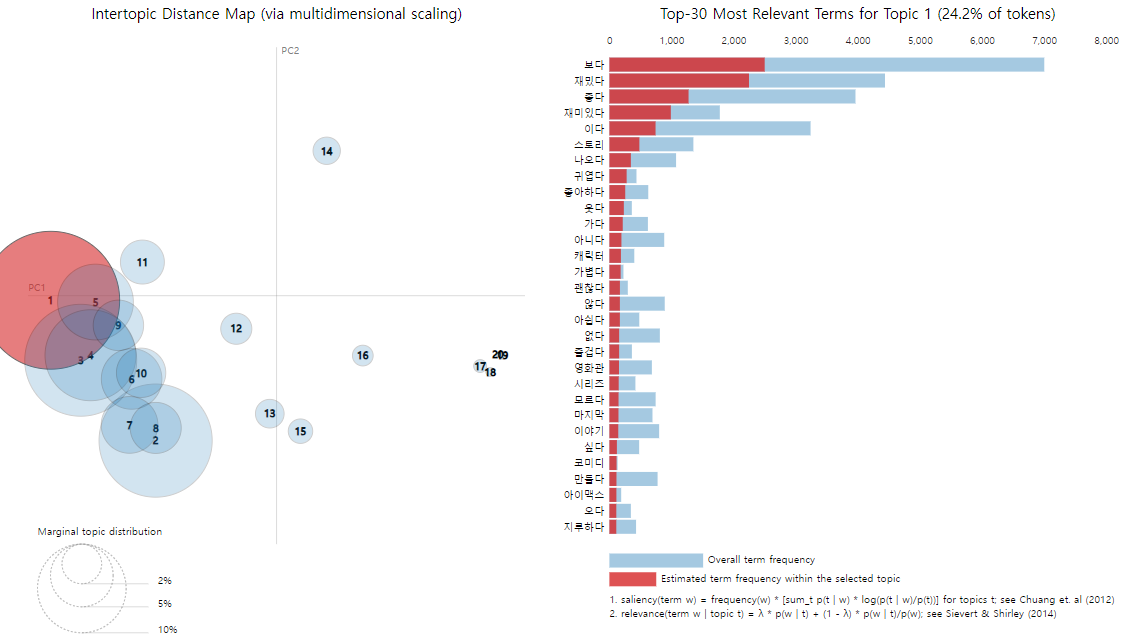

In [ ]:
# 부정리뷰
reviews_movie_li2 = reviews_movie_li.dropna(subset=['부정리뷰'])
tokenized_doc = reviews_movie_li2.reset_index(drop=True)

X_train = []
for sentence in tokenized_doc['부정리뷰']:
    sentence = " ".join(sentence)
    tokenized_sentence = okt.morphs(sentence, stem=True) # 토큰화
    stopwords_removed_sentence = [word for word in tokenized_sentence if not word in stopwords] # 불용어 제거
    X_train.append(stopwords_removed_sentence)

print(X_train[:3])

tokenized_doc['부정리뷰'] = X_train

# 이제 각 단어에 정수 인코딩을 하는 동시에, 각 리뷰에서의 단어의 빈도수를 기록
from gensim import corpora

# 용어-문서 빈도
dictionary = corpora.Dictionary(tokenized_doc['부정리뷰'])
corpus = [dictionary.doc2bow(text) for text in tokenized_doc['부정리뷰']]
print(corpus[1]) # 수행된 결과에서 두번째 영화 리뷰 출력. 첫번째 문서의 인덱스는 0

# (72, 5) : 정수 인코딩이 72, 다섯 번 출력

NUM_TOPICS = 20

# LDA 모델링
ldamodel = gensim.models.ldamodel.LdaModel(corpus, num_topics = NUM_TOPICS, id2word=dictionary, passes=35)
# passes는 알고리즘의 동작 횟수를 말하는데,
# 알고리즘이 결정하는 토픽의 값이 적절히 수렴할 수 있도록 충분히 적당한 횟수

topics = ldamodel.print_topics(num_words=10)
for topic in topics:
    print(topic)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


[[], ['1990년', '대다', '만들어지다', '영화', '아무리', '아니다', '넘어서다', '이렇게', '좋다', '모르다', '아깝다', '숨쉬다', '재미없다', '쯨즛퓨', '정직하다', '이렇다', '이야기', '195', '만큼이나', '아득하다', '느껴지다', '가능하다', '서윤복', '이라는', '해주다', '이다', '에서는', '보스턴', '마라톤', '에서는', '시종일관', '힘들다', '만들다', '기괴하다', '이다', '잘알다', '않다', '화이자', '역사왜곡', '부추기다', '그럭저럭', '받다', '보다', '찾아보다'], ['지금껏', '부실하다', '스토리', '매끄럽다', '산만하다', '어색하다', '불편하다', '부족하다', '아쉬움', '가득하다', '무겁다', '만들다', '백성현', '사투리', '어색하다', '눈뜨다', '너무나도', '부족하다', '보다', '넣다', '아니다', '아쉽다', '이래저래', '아쉽다', '스토리', '부족함', '어색하다', '영화로', '적격하다', '80년', '보다', '1980년', '만들어지다', '1980', '1980', 'The', 'Unforgettable', 'Day', '2024', '재미있다', '보다', '긴장감', '재다', '보다']]
[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 2), (26, 1), (27, 1), (28, 2), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1),

In [ ]:
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(ldamodel, corpus, dictionary)
vis

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.117919  0.009765       1        1  29.688326
13     0.105263 -0.028953       2        1  12.191583
18     0.117410  0.002292       3        1   9.565746
11     0.100513 -0.051139       4        1   9.493518
14     0.070168  0.198100       5        1   5.029158
2      0.078059 -0.051260       6        1   4.945493
7      0.071528  0.035210       7        1   4.428919
4      0.008284 -0.072356       8        1   3.619855
16     0.011265  0.030031       9        1   2.831903
17     0.003269 -0.041794      10        1   2.565354
6     -0.016945  0.004313      11        1   2.381716
19    -0.017664 -0.009157      12        1   2.333664
15    -0.001361 -0.040953      13        1   2.298183
9     -0.034872 -0.035016      14        1   2.116777
5     -0.018293  0.012615      15        1   1.795645
8     -0.126211  0.003869      16        1   1.172503
10    -0.121143  0.045661      17        1   1.031202
3     -0.092699 -0.022578      18        1   0.937946
1     -0.104001 -0.016179      19        1   0.905934
12    -0.150487  0.027530      20        1   0.666575, topic_info=     Term        Freq       Total Category  logprob  loglift
14     보다  435.000000  435.000000  Default  30.0000  30.0000
369   디즈니   54.000000   54.000000  Default  29.0000  29.0000
111   드라마   41.000000   41.000000  Default  28.0000  28.0000
126   나오다  207.000000  207.000000  Default  27.0000  27.0000
12    모르다  170.000000  170.000000  Default  26.0000  26.0000
..    ...         ...         ...      ...      ...      ...
334   강하다    0.446458    7.627826  Topic20  -5.3939   2.1726
811   으로만    0.446458    6.163964  Topic20  -5.3939   2.3856
268  훌륭하다    0.446458   16.692188  Topic20  -5.3939   1.3894
371  열광하다    0.446458    4.739816  Topic20  -5.3939   2.6484
631   귀엽다    0.446458   22.969802  Topic20  -5.3939   1.0702

[1291 rows x 6 columns], token_table=      Topic      Freq    Term
term                         
2357      5  0.976081     100
2358      5  0.829715    100년
897      16  0.780293  10500원
565      13  0.699117    110분
1646     19  0.819882     13일
...     ...       ...     ...
41       11  0.028635     힘들다
41       14  0.028635     힘들다
41       15  0.028635     힘들다
41       16  0.057270     힘들다
41       19  0.028635     힘들다

[2330 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 14, 19, 12, 15, 3, 8, 5, 17, 18, 7, 20, 16, 10, 6, 9, 11, 4, 2, 13])

> 부정 리뷰 토픽 확인

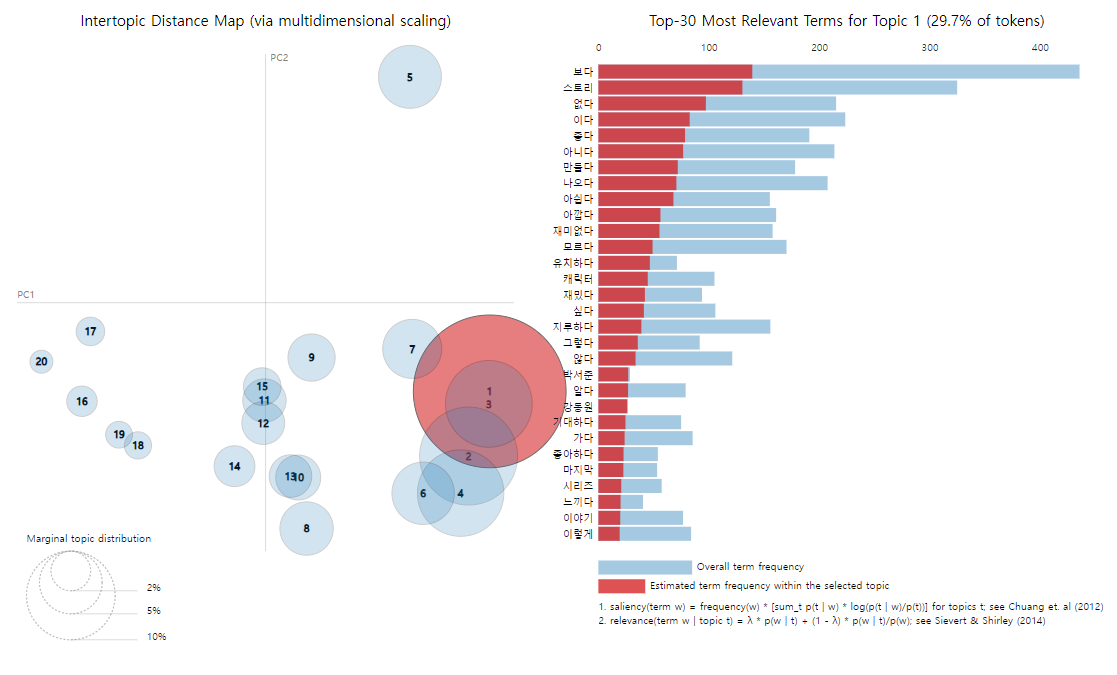

### 영화별 토픽확인

In [94]:
# 각 문서에 대한 토픽 분포를 출력하는 코드(즉, 특정 문서에 대한 모델의 토픽 예측 코드)
def make_topictable_per_doc(ldamodel, corpus):
    topic_table = pd.DataFrame()

    # 몇 번째 문서인지를 의미하는 문서 번호와 해당 문서의 토픽 비중을 한 줄씩 꺼내온다.
    for i, topic_list in enumerate(ldamodel[corpus]):
        doc = topic_list[0] if ldamodel.per_word_topics else topic_list
        doc = sorted(doc, key=lambda x: (x[1]), reverse=True)
        # 각 문서에 대해서 비중이 높은 토픽순으로 토픽을 정렬한다.
        # EX) 정렬 전 0번 문서 : (2번 토픽, 48.5%), (8번 토픽, 25%), (10번 토픽, 5%), (12번 토픽, 21.5%),
        # Ex) 정렬 후 0번 문서 : (2번 토픽, 48.5%), (8번 토픽, 25%), (12번 토픽, 21.5%), (10번 토픽, 5%)
        # 48 > 25 > 21 > 5 순으로 정렬이 된 것.

        # 모든 문서에 대해서 각각 아래를 수행
        for j, (topic_num, prop_topic) in enumerate(doc): #  몇 번 토픽인지와 비중을 나눠서 저장한다.
            if j == 0:  # 정렬을 한 상태이므로 가장 앞에 있는 것이 가장 비중이 높은 토픽
                tp = pd.DataFrame(data= {'topic_num':int(topic_num),
                                   'prop_topic':round(prop_topic,5),
                                   'topic_list':topic_list
                                   }
                                  )
                topic_table = pd.concat([topic_table,tp])
                # 가장 비중이 높은 토픽과, 가장 비중이 높은 토픽의 비중과, 전체 토픽의 비중을 저장한다.
            else:
                break
    return(topic_table)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [97]:
topictable = make_topictable_per_doc(ldamodel, corpus)

topictable = topictable.reset_index() # 문서 번호을 의미하는 열(column)로 사용하기 위해서 인덱스 열을 하나 더 만든다.
topictable.columns = ['문서 번호', '가장 비중이 높은 토픽', '가장 높은 토픽의 비중', '각 토픽의 비중']
topictable[:30]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,문서 번호,가장 비중이 높은 토픽,가장 높은 토픽의 비중,각 토픽의 비중
0,0,0,0.0500,"(0, 0.05)"
1,1,0,0.0500,"(1, 0.05)"
2,2,0,0.0500,"(2, 0.05)"
3,3,0,0.0500,"(3, 0.05)"
4,4,0,0.0500,"(4, 0.05)"
5,5,0,0.0500,"(5, 0.05)"
6,6,0,0.0500,"(6, 0.05)"
7,7,0,0.0500,"(7, 0.05)"
8,8,0,0.0500,"(8, 0.05)"
9,9,0,0.0500,"(9, 0.05)"
